# AtliQ Grands - Hospitality Data Analysis

## Objective

The goal of this project is to analyze the AtliQ Grands dataset by solving a set of structured questions.

The work includes:
- understanding the dataset structure
- cleaning and preparing the data
- solving specific questions step by step
- using visualizations where needed
- writing clear insights from each analysis

The main focus is to break down problems into smaller parts and extract meaningful insights from the data.

## Structure of Analysis

The notebook is organized into multiple sections. Each section focuses on one question.

For every question:
- relevant data is selected
- analysis is performed
- results are visualized (if needed)
- a simple insight is written

## Problem Context

AtliQ Grands is a chain of five-star hotels operating across India for the past 20 years.

Recently, the company has been losing market share and revenue due to increased competition and ineffective decision-making.

This analysis aims to use historical data to understand booking patterns and identify areas for improvement.

In [183]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Import and Exploration

### Datasets

We are using the following datasets:

- dim_date.csv  
- dim_hotels.csv  
- dim_rooms.csv  
- fact_aggregated_bookings.csv  
- fact_bookings.csv  

### Load Bookings Data

In [184]:
df_bookings = pd.read_csv("datasets/fact_bookings.csv")

### Explore Bookings Data

In [185]:
df_bookings.head(5)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920


In [186]:
df_bookings.shape

(134590, 12)

In [187]:
df_bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134590 entries, 0 to 134589
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   booking_id         134590 non-null  object 
 1   property_id        134590 non-null  int64  
 2   booking_date       134590 non-null  object 
 3   check_in_date      134590 non-null  object 
 4   checkout_date      134590 non-null  object 
 5   no_guests          134587 non-null  float64
 6   room_category      134590 non-null  object 
 7   booking_platform   134590 non-null  object 
 8   ratings_given      56683 non-null   float64
 9   booking_status     134590 non-null  object 
 10  revenue_generated  134590 non-null  int64  
 11  revenue_realized   134590 non-null  int64  
dtypes: float64(2), int64(3), object(7)
memory usage: 12.3+ MB


In [188]:
df_bookings.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134590.000000,134587.000000,56683.000000,1.345900e+05,134590.000000
mean,18061.113493,2.036170,3.619004,1.537805e+04,12696.123256
std,1093.055847,1.034885,1.235009,9.303604e+04,6928.108124
min,16558.000000,-17.000000,1.000000,6.500000e+03,2600.000000
25%,17558.000000,1.000000,3.000000,9.900000e+03,7600.000000
50%,17564.000000,2.000000,4.000000,1.350000e+04,11700.000000
75%,18563.000000,2.000000,5.000000,1.800000e+04,15300.000000
max,19563.000000,6.000000,5.000000,2.856000e+07,45220.000000


### Booking Platform and Room Category Analysis

In [189]:
df_bookings["room_category"].unique()

array(['RT1', 'RT2', 'RT3', 'RT4'], dtype=object)

In [190]:
df_bookings["booking_platform"].unique()

array(['direct online', 'others', 'logtrip', 'tripster', 'makeyourtrip',
       'journey', 'direct offline'], dtype=object)

In [191]:
df_bookings["booking_platform"].value_counts()

booking_platform
others            55066
makeyourtrip      26898
logtrip           14756
direct online     13379
tripster           9630
journey            8106
direct offline     6755
Name: count, dtype: int64

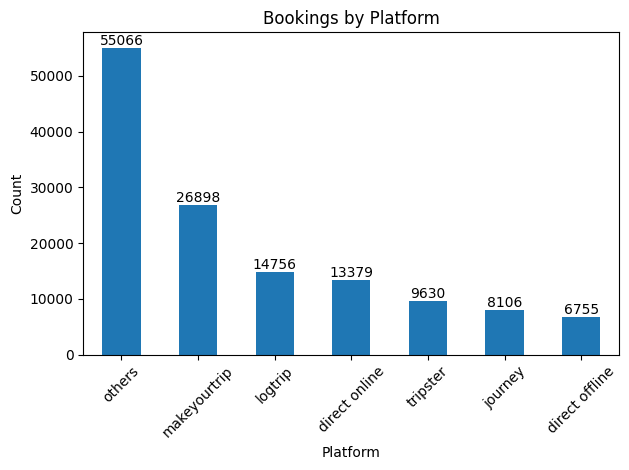

In [192]:
platform_counts = df_bookings["booking_platform"].value_counts()

ax = platform_counts.plot(kind="bar")

# Labels on bars
for i, value in enumerate(platform_counts):
    ax.text(i, value, str(value), ha='center', va='bottom')

plt.title("Bookings by Platform")
plt.xlabel("Platform")
plt.ylabel("Count")

plt.xticks(rotation=45)  # rotate labels

plt.tight_layout()  # prevents cutting labels
# plt.savefig("bookings_by_platform.png",bbox_inches='tight') -- to save chart as image
plt.show()

Insight:
Different booking platforms contribute differently to total bookings. Some platforms clearly dominate in terms of usage.

### Load Other Datasets

In [193]:
df_date = pd.read_csv("datasets/dim_date.csv")
df_hotels = pd.read_csv("datasets/dim_hotels.csv")
df_rooms = pd.read_csv("datasets/dim_rooms.csv")
df_agg_bookings = pd.read_csv("datasets/fact_aggregated_bookings.csv")

### Explore Hotels Data

In [194]:
df_hotels.shape

(25, 4)

In [195]:
df_hotels.head(3)

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi


In [196]:
df_hotels["category"].value_counts()

category
Luxury      16
Business     9
Name: count, dtype: int64

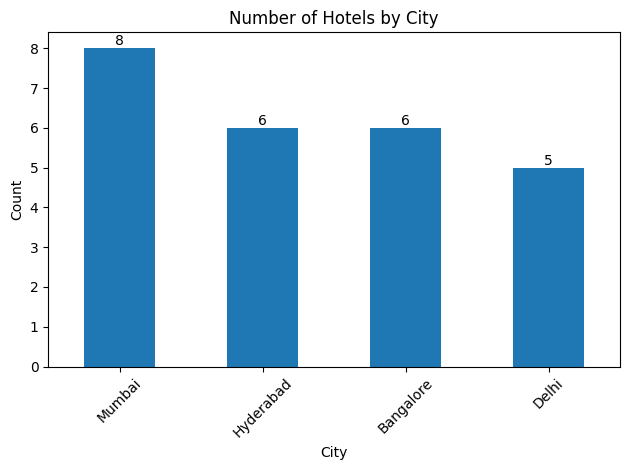

In [197]:
city_counts = df_hotels["city"].value_counts()

ax = city_counts.plot(kind="bar")

# Add labels on bars
for i, value in enumerate(city_counts):
    ax.text(i, value, str(value), ha='center', va='bottom')

plt.title("Number of Hotels by City")
plt.xlabel("City")
plt.ylabel("Count")

plt.xticks(rotation=45)   # rotate for readability
plt.tight_layout()        # avoid overlap
#plt.savefig("no_of_hotels_by_city.png", bbox_inches='tight') -- to save chart as image
plt.show()

Insight:
Hotel distribution varies across cities, with some cities having a higher number of properties.

### Exercises on Aggregate Bookings Data

In [198]:
df_agg_bookings.head(3)

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,1-May-22,RT1,25,30.0
1,19562,1-May-22,RT1,28,30.0
2,19563,1-May-22,RT1,23,30.0


#### Question 1: Find unique property IDs

In [199]:
df_agg_bookings["property_id"].unique()

array([16559, 19562, 19563, 17558, 16558, 17560, 19558, 19560, 17561,
       16560, 16561, 16562, 16563, 17559, 17562, 17563, 18558, 18559,
       18561, 18562, 18563, 19559, 19561, 17564, 18560])

Insight:
The dataset contains multiple properties, each identified by a unique property ID.

#### Question 2: Total bookings per property

In [200]:
df_agg_bookings.groupby("property_id")["successful_bookings"].sum().reset_index()

,property_id,successful_bookings
0,16558,3153
1,16559,7338
2,16560,4693
3,16561,4418
4,16562,4820
5,16563,7211
6,17558,5053
7,17559,6142
8,17560,6013
9,17561,5183


Insight:
Some properties receive significantly more bookings, indicating higher demand.

#### Question 3: Days when bookings exceed capacity

In [201]:
df_agg_bookings[
    df_agg_bookings["successful_bookings"] > df_agg_bookings["capacity"]
]

,property_id,check_in_date,room_category,successful_bookings,capacity
3,17558,1-May-22,RT1,30,19.0
12,16563,1-May-22,RT1,100,41.0
4136,19558,11-Jun-22,RT2,50,39.0
6209,19560,2-Jul-22,RT1,123,26.0
8522,19559,25-Jul-22,RT1,35,24.0
9194,18563,31-Jul-22,RT4,20,18.0


Insight:
There are cases where bookings exceed capacity, which may indicate data issues or overbooking scenarios.

#### Question 4: Properties with highest capacity

In [202]:
max_capacity = df_agg_bookings["capacity"].max()
df_agg_bookings[df_agg_bookings["capacity"] == max_capacity]

,property_id,check_in_date,room_category,successful_bookings,capacity
27,17558,1-May-22,RT2,38,50.0
128,17558,2-May-22,RT2,27,50.0
229,17558,3-May-22,RT2,26,50.0
328,17558,4-May-22,RT2,27,50.0
428,17558,5-May-22,RT2,29,50.0
...,...,...,...,...,...
8728,17558,27-Jul-22,RT2,22,50.0
8828,17558,28-Jul-22,RT2,21,50.0
8928,17558,29-Jul-22,RT2,23,50.0
9028,17558,30-Jul-22,RT2,32,50.0


Insight:
These properties have the highest accommodation capacity among all listed properties.

## 2. Data Cleaning

### Initial Data Inspection

In [203]:
df_bookings.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134590.000000,134587.000000,56683.000000,1.345900e+05,134590.000000
mean,18061.113493,2.036170,3.619004,1.537805e+04,12696.123256
std,1093.055847,1.034885,1.235009,9.303604e+04,6928.108124
min,16558.000000,-17.000000,1.000000,6.500000e+03,2600.000000
25%,17558.000000,1.000000,3.000000,9.900000e+03,7600.000000
50%,17564.000000,2.000000,4.000000,1.350000e+04,11700.000000
75%,18563.000000,2.000000,5.000000,1.800000e+04,15300.000000
max,19563.000000,6.000000,5.000000,2.856000e+07,45220.000000


### 1. Remove Invalid Guest Records

Some records have number of guests less than or equal to 0, which is not valid.
These rows are removed to ensure data accuracy.

In [204]:
df_bookings[df_bookings["no_guests"] <= 0]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
17924,May122218559RT44,18559,12/5/2022,12/5/2022,14-05-22,-10.0,RT4,direct online,NaN,No Show,20900,20900
18020,May122218561RT22,18561,8/5/2022,12/5/2022,14-05-22,-12.0,RT2,makeyourtrip,NaN,Cancelled,9000,3600
18119,May122218562RT311,18562,5/5/2022,12/5/2022,17-05-22,-6.0,RT3,direct offline,5.0,Checked Out,16800,16800
18121,May122218562RT313,18562,10/5/2022,12/5/2022,17-05-22,-4.0,RT3,direct online,NaN,Cancelled,14400,5760
56715,Jun082218562RT12,18562,5/6/2022,8/6/2022,13-06-22,-17.0,RT1,others,NaN,Checked Out,6500,6500
119765,Jul202219560RT220,19560,19-07-22,20-07-22,22-07-22,-1.0,RT2,others,NaN,Checked Out,13500,13500
134586,Jul312217564RT47,17564,30-07-22,31-07-22,1/8/2022,-4.0,RT4,logtrip,2.0,Checked Out,38760,38760


In [205]:
df_bookings = df_bookings[df_bookings["no_guests"] > 0]
df_bookings.shape

(134578, 12)

### 2. Outlier Removal in Revenue Generated

We use the 3 standard deviation rule to identify extreme values.

In [206]:
df_bookings["revenue_generated"].min(), df_bookings["revenue_generated"].max()

(np.int64(6500), np.int64(28560000))

In [207]:
df_bookings["revenue_generated"].mean(), df_bookings["revenue_generated"].median()

(np.float64(15378.036937686695), np.float64(13500.0))

In [208]:
avg = df_bookings["revenue_generated"].mean()
std = df_bookings["revenue_generated"].std()

upper_limit = avg + 3 * std
lower_limit = avg - 3 * std

upper_limit, lower_limit

(np.float64(294498.50173207896), np.float64(-263742.4278567056))

In [209]:
df_bookings[df_bookings["revenue_generated"] <= 0]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized


In [210]:
df_bookings[df_bookings["revenue_generated"] > upper_limit]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
111,May012216559RT32,16559,29-04-22,1/5/2022,2/5/2022,6.0,RT3,direct online,NaN,Checked Out,28560000,28560
315,May012216562RT22,16562,28-04-22,1/5/2022,4/5/2022,2.0,RT2,direct offline,3.0,Checked Out,12600000,12600
562,May012217559RT118,17559,26-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,2000000,4420
129176,Jul282216562RT26,16562,21-07-22,28-07-22,29-07-22,2.0,RT2,direct online,3.0,Checked Out,10000000,12600


In [211]:
df_bookings = df_bookings[df_bookings["revenue_generated"] <= upper_limit]
df_bookings.shape

(134573, 12)

Insight:
Extreme high values in revenue were removed to avoid skewed analysis results.

### 3. Check Outliers in Revenue Realized

In [212]:
df_bookings["revenue_realized"].describe()

count    134573.000000
mean      12695.983585
std        6927.791692
min        2600.000000
25%        7600.000000
50%       11700.000000
75%       15300.000000
max       45220.000000
Name: revenue_realized, dtype: float64

In [213]:
upper_limit = (
    df_bookings["revenue_realized"].mean() +
    3 * df_bookings["revenue_realized"].std()
)

upper_limit

np.float64(33479.358661845814)

In [214]:
df_bookings[df_bookings["revenue_realized"] > upper_limit]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
137,May012216559RT41,16559,27-04-22,1/5/2022,7/5/2022,4.0,RT4,others,NaN,Checked Out,38760,38760
139,May012216559RT43,16559,1/5/2022,1/5/2022,2/5/2022,6.0,RT4,tripster,3.0,Checked Out,45220,45220
143,May012216559RT47,16559,28-04-22,1/5/2022,3/5/2022,3.0,RT4,others,5.0,Checked Out,35530,35530
149,May012216559RT413,16559,24-04-22,1/5/2022,7/5/2022,5.0,RT4,logtrip,NaN,Checked Out,41990,41990
222,May012216560RT45,16560,30-04-22,1/5/2022,3/5/2022,5.0,RT4,others,3.0,Checked Out,34580,34580
...,...,...,...,...,...,...,...,...,...,...,...,...
134328,Jul312219560RT49,19560,31-07-22,31-07-22,2/8/2022,6.0,RT4,direct online,5.0,Checked Out,39900,39900
134331,Jul312219560RT412,19560,31-07-22,31-07-22,1/8/2022,6.0,RT4,others,2.0,Checked Out,39900,39900
134467,Jul312219562RT45,19562,28-07-22,31-07-22,1/8/2022,6.0,RT4,makeyourtrip,4.0,Checked Out,39900,39900
134474,Jul312219562RT412,19562,25-07-22,31-07-22,6/8/2022,5.0,RT4,direct offline,5.0,Checked Out,37050,37050


Observation:
The records with high revenue belong to room category RT4 (premium rooms).

In [215]:
df_bookings[df_bookings["room_category"] == "RT4"]["revenue_realized"].describe()

count    16071.000000
mean     23439.308444
std       9048.599076
min       7600.000000
25%      19000.000000
50%      26600.000000
75%      32300.000000
max      45220.000000
Name: revenue_realized, dtype: float64

Insight:
Higher revenue values are expected for premium rooms (RT4), so no outlier removal is required for this column.

### 4. Handling Missing Values

In [216]:
df_bookings.isnull().sum()

booking_id               0
property_id              0
booking_date             0
check_in_date            0
checkout_date            0
no_guests                0
room_category            0
booking_platform         0
ratings_given        77897
booking_status           0
revenue_generated        0
revenue_realized         0
dtype: int64

Insight:
The ratings column contains many null values. These values are not removed or replaced to avoid introducing bias.

### Exercise 1: Handle Missing Values in Aggregate Bookings

In [217]:
df_agg_bookings.isnull().sum()

property_id            0
check_in_date          0
room_category          0
successful_bookings    0
capacity               2
dtype: int64

In [218]:
df_agg_bookings[df_agg_bookings["capacity"].isna()]

,property_id,check_in_date,room_category,successful_bookings,capacity
8,17561,1-May-22,RT1,22,NaN
14,17562,1-May-22,RT1,12,NaN


In [219]:
median_capacity = df_agg_bookings["capacity"].median()
median_capacity

np.float64(25.0)

In [220]:
df_agg_bookings["capacity"] = df_agg_bookings["capacity"].fillna(median_capacity)

In [221]:
df_agg_bookings.loc[[8, 15]]

,property_id,check_in_date,room_category,successful_bookings,capacity
8,17561,1-May-22,RT1,22,25.0
15,17563,1-May-22,RT1,21,25.0


Insight:
Missing capacity values were replaced using median to maintain data consistency.

### Exercise 2: Remove Invalid Booking Records

Filter records where successful bookings exceed capacity.

In [222]:
df_agg_bookings[
    df_agg_bookings["successful_bookings"] > df_agg_bookings["capacity"]
]

,property_id,check_in_date,room_category,successful_bookings,capacity
3,17558,1-May-22,RT1,30,19.0
12,16563,1-May-22,RT1,100,41.0
4136,19558,11-Jun-22,RT2,50,39.0
6209,19560,2-Jul-22,RT1,123,26.0
8522,19559,25-Jul-22,RT1,35,24.0
9194,18563,31-Jul-22,RT4,20,18.0


In [223]:
df_agg_bookings.shape

(9200, 5)

In [224]:
df_agg_bookings = df_agg_bookings[
    df_agg_bookings["successful_bookings"] <= df_agg_bookings["capacity"]
]

In [225]:
df_agg_bookings.shape

(9194, 5)

Insight:
Invalid records where bookings exceeded capacity were removed to ensure realistic analysis.

## 3. Data Transformation

### Data Transformation

In this section, we create new columns and prepare the data for further analysis.

Common transformations include:
- creating new columns  
- aggregation  
- merging datasets  
- formatting values  

### Create Occupancy Percentage Column

Occupancy percentage represents how much of the available capacity is utilized.

In [226]:
df_agg_bookings["occ_pct"] = (
    df_agg_bookings["successful_bookings"] / df_agg_bookings["capacity"]
)

### Convert to Percentage Format

In [227]:
df_agg_bookings["occ_pct"] = (df_agg_bookings["occ_pct"] * 100).round(2)

In [228]:
df_agg_bookings.head(3)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct
0,16559,1-May-22,RT1,25,30.0,83.33
1,19562,1-May-22,RT1,28,30.0,93.33
2,19563,1-May-22,RT1,23,30.0,76.67


Insight:
The occupancy percentage column helps measure how efficiently hotel capacity is being utilized.

### Data Check After Transformation

In [229]:
df_agg_bookings.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9194 entries, 0 to 9199
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_id          9194 non-null   int64  
 1   check_in_date        9194 non-null   object 
 2   room_category        9194 non-null   object 
 3   successful_bookings  9194 non-null   int64  
 4   capacity             9194 non-null   float64
 5   occ_pct              9194 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 502.8+ KB


In [230]:
df_agg_bookings.head(5)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct
0,16559,1-May-22,RT1,25,30.0,83.33
1,19562,1-May-22,RT1,28,30.0,93.33
2,19563,1-May-22,RT1,23,30.0,76.67
4,16558,1-May-22,RT1,18,19.0,94.74
5,17560,1-May-22,RT1,28,40.0,70.00


## 4. Insights Generation

### Prepare Combined Dataset

In [231]:
df = df_agg_bookings.merge(df_rooms, left_on="room_category", right_on="room_id")

df = df.merge(df_hotels, on="property_id")

df_date["date"] = pd.to_datetime(
    df_date["date"],
    format="%d-%b-%y"
)

df["check_in_date"] = pd.to_datetime(
    df["check_in_date"],
    format="%d-%b-%y"
)

df = df.merge(df_date, left_on="check_in_date", right_on="date")

df.head(3)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_id,room_class,property_name,category,city,date,mmm yy,week no,day_type
0,16559,2022-05-01,RT1,25,30.0,83.33,RT1,Standard,Atliq Exotica,Luxury,Mumbai,2022-05-01,May 22,W 19,weekend
1,19562,2022-05-01,RT1,28,30.0,93.33,RT1,Standard,Atliq Bay,Luxury,Bangalore,2022-05-01,May 22,W 19,weekend
2,19563,2022-05-01,RT1,23,30.0,76.67,RT1,Standard,Atliq Palace,Business,Bangalore,2022-05-01,May 22,W 19,weekend


Insight:
A combined dataset is created to simplify analysis and avoid repeated merging.

### Question 1: Average occupancy rate by room category

In [232]:
df.groupby("room_class")["occ_pct"].mean().round(2)

room_class
Elite           58.01
Premium         58.03
Presidential    59.28
Standard        57.89
Name: occ_pct, dtype: float64

Insight:
Different room categories show varying occupancy levels, indicating differences in demand.

### Question 2: Average occupancy rate by city

In [233]:
df.groupby("city")["occ_pct"].mean().round(2)

city
Bangalore    56.33
Delhi        61.51
Hyderabad    58.12
Mumbai       57.91
Name: occ_pct, dtype: float64

Insight:
Some cities have consistently higher occupancy, showing stronger demand in those locations.

### Question 3: Occupancy comparison - Weekday vs Weekend

In [234]:
df.groupby("day_type")["occ_pct"].mean().round(2)

day_type
weekeday    51.81
weekend     73.96
Name: occ_pct, dtype: float64

Insight:
Occupancy differs between weekdays and weekends, reflecting customer booking patterns.

### Question 4: Occupancy by city in June

In [235]:
df_june = df[df["mmm yy"] == "Jun 22"]
city_occ = df_june.groupby("city")["occ_pct"].mean().round(2).sort_values(ascending=False)
city_occ

city
Delhi        61.46
Mumbai       57.79
Hyderabad    57.69
Bangalore    55.85
Name: occ_pct, dtype: float64

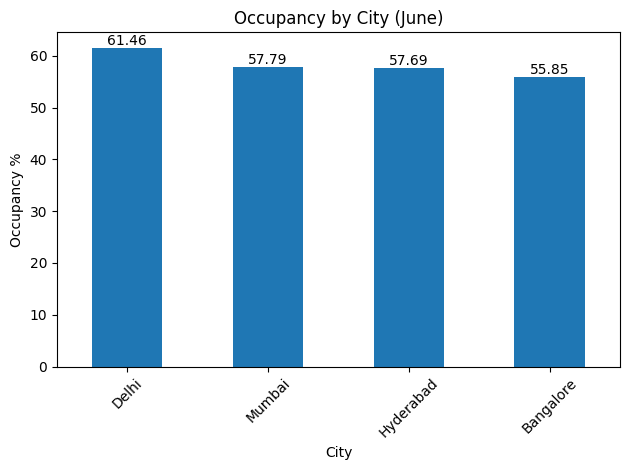

In [236]:
ax = city_occ.plot(kind="bar")

for i, value in enumerate(city_occ):
    ax.text(i, value, str(value), ha='center', va='bottom')

plt.title("Occupancy by City (June)")
plt.xlabel("City")
plt.ylabel("Occupancy %")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight:
Some cities perform better during June, indicating seasonal demand differences.

### Question 5: Append new data (August)

In [237]:
df_august = pd.read_csv("datasets/new_data_august.csv")
latest_df = pd.concat([df, df_august], ignore_index=True)
latest_df.shape

(9201, 16)

Insight:
New data is appended to keep the dataset updated for future analysis.

### Question 6: Revenue realized per city

In [238]:
df_bookings_all = df_bookings.merge(df_hotels, on="property_id")
df_bookings_all.groupby("city")["revenue_realized"].sum().round(2)

city
Bangalore    420383550
Delhi        294404488
Hyderabad    325179310
Mumbai       668569251
Name: revenue_realized, dtype: int64

Insight:
Revenue varies across cities, indicating differences in performance and demand.

### Question 7: Month-wise revenue

In [239]:
df_bookings_all["check_in_date"] = pd.to_datetime(
    df_bookings_all["check_in_date"],
    format="mixed",
    dayfirst=True
)

df_bookings_all = df_bookings_all.merge(
    df_date,
    left_on="check_in_date",
    right_on="date"
)

df_bookings_all.groupby("mmm yy")["revenue_realized"].sum().round(2)

mmm yy
Jul 22    572843348
Jun 22    553925855
May 22    581767396
Name: revenue_realized, dtype: int64

Insight:
Revenue changes across months, showing seasonal business trends.

### Exercise 1: Revenue per hotel

In [240]:
df_bookings_all.groupby("property_name")["revenue_realized"].sum().round(2).sort_values(ascending=False)

property_name
Atliq Exotica    320258588
Atliq Palace     304081863
Atliq City       285798439
Atliq Blu        260851922
Atliq Bay        259996918
Atliq Grands     211462134
Atliq Seasons     66086735
Name: revenue_realized, dtype: int64

Insight:
Some hotels generate significantly higher revenue compared to others.

### Exercise 2: Average rating per city

In [241]:
df_bookings_all.groupby("city")["ratings_given"].mean().round(2)

city
Bangalore    3.41
Delhi        3.78
Hyderabad    3.66
Mumbai       3.65
Name: ratings_given, dtype: float64

Insight:
Average ratings vary by city, reflecting differences in customer experience.

### Exercise 3: Revenue share by booking platform

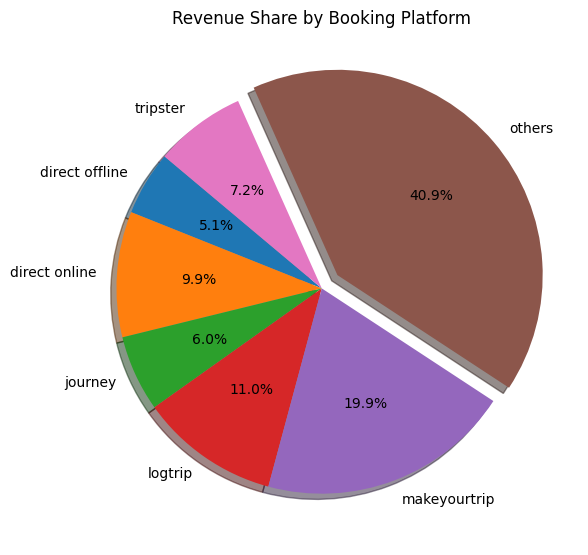

In [242]:
platform_rev = df_bookings_all.groupby("booking_platform")["revenue_realized"].sum()

# explode biggest slice
explode = [0.1 if i == platform_rev.idxmax() else 0 for i in platform_rev.index]

plt.figure(figsize=(6,6))

platform_rev.plot(
    kind="pie",
    autopct='%1.1f%%',
    startangle=140,      # rotate chart
    explode=explode,     # highlight biggest slice
    shadow=True,         # slight shadow effect
)

plt.title("Revenue Share by Booking Platform")
plt.ylabel("")           # remove default label

plt.tight_layout()
#plt.savefig("revenue_share_by_booking_platform.png", bbox_inches='tight') -- to save chart as image
plt.show()

Insight:
Some booking platforms contribute more to total revenue than others.

## Key Insights

- Occupancy varies across room categories, showing differences in demand.
- Some cities consistently perform better in terms of occupancy and revenue.
- Weekend and weekday occupancy patterns are different, indicating customer behavior trends.
- Seasonal trends are visible, with certain months showing higher revenue.
- Booking platforms contribute differently to overall revenue, with some platforms dominating.
- A few hotels generate significantly higher revenue compared to others.

## Conclusion

This analysis explored hotel booking data by solving multiple questions related to occupancy, revenue, and customer behavior.

The findings highlight key patterns across cities, room types, and booking platforms. These insights can help in understanding business performance and identifying areas for improvement.

The project also demonstrates a structured approach to data analysis, including data cleaning, transformation, and insight generation.

## What I Learned

- how to clean and prepare real-world data  
- how to handle missing values and outliers  
- how to work with multiple datasets and merge them  
- how to structure analysis using questions  
- how to present insights clearly using simple explanations  